In this notebook I'm performing some experiments with 1D vs 2D Gaussian fitting. Let's run an MSE on kdv data until the first sparsity update:

In [1]:
# %% Imports
from jax import random, numpy as jnp

from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from flax import optim
from modax.losses.bayesian import loss_fn_mse_precalc
from modax.training import train_probabilistic_mse
from conditional_gaussian import *

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.1 * jnp.std(y) * random.normal(key, y.shape)

In [54]:
0.1 * jnp.std(u)

DeviceArray(0.05760131, dtype=float32)

In [19]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [20]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_mse_precalc,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 214.76449584960938
Loss step 1000.0: -301.3000183105469


In [24]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

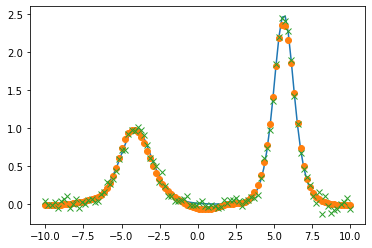

In [36]:
frame = 10
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

Which is pretty good. If we would calculate the mse and reg at this point, we'd get:

In [3]:
from jax.scipy.stats import norm

In [56]:
sigma_mse = jnp.sqrt(jnp.mean((y - prediction)**2))
L_mse = jnp.sum(norm.logpdf((y-prediction), scale=sigma_mse))

print(sigma_mse, L_mse)

0.062522985 1353.2825


In [57]:
sigma_reg = jnp.sqrt(jnp.mean((dt - theta @ coeffs)**2))
L_reg = jnp.sum(norm.logpdf((dt-theta @ coeffs), scale=sigma_reg))

print(sigma_reg, L_reg)

0.45428684 -629.9121


And the coeffs:

In [49]:
coeffs * jnp.linalg.norm(theta, axis=0)[:, None]

DeviceArray([[   1.2630763],
             [ -23.35378  ],
             [ -10.6313095],
             [ -76.34257  ],
             [  -4.4297037],
             [-160.32687  ],
             [  48.971977 ],
             [ 128.74684  ],
             [   9.036601 ],
             [  93.76756  ],
             [ -33.696545 ],
             [ -56.422215 ]], dtype=float32)

Which seems reasonable; if we would've trained with a pinn it wouldn't have worked.

Now what would these values be if the regression term were a 2D Gaussian together with the mse?

In [4]:
from jax.scipy.stats import multivariate_normal

In [67]:
obs = jnp.concatenate([y - prediction, dt - theta @ coeffs], axis=1)
rho = jnp.corrcoef(obs.T)[0, 1]
cov = jnp.array([[sigma_mse**2, rho * sigma_mse * sigma_reg], 
                 [rho * sigma_mse * sigma_reg, sigma_reg**2]])

In [68]:
cov

DeviceArray([[0.00390912, 0.00164954],
             [0.00164954, 0.20637654]], dtype=float32)

In [76]:
L_reg_2D = jnp.sum(multivariate_normal.logpdf(obs, mean=jnp.zeros((2, )), cov=cov))

Doesn't seem unreasonable... Let's build a loss function:

In [21]:
def loss_fn_2d(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    sigma_mse = jnp.sqrt(jnp.mean((y - prediction)**2))
    sigma_reg = jnp.maximum(jnp.sqrt(jnp.mean((dt - theta @ coeffs)**2)), 1e-2)
    
    p_mse = jnp.sum(norm.logpdf((y-prediction), scale=sigma_mse))
    
    obs = jnp.concatenate([y - prediction, dt - theta @ coeffs], axis=1)
    rho = jnp.corrcoef(obs.T)[0, 1]
    cov = jnp.array([[sigma_mse**2, rho * sigma_mse * sigma_reg], [rho * sigma_mse * sigma_reg, sigma_reg**2]])
    p_reg = jnp.sum(multivariate_normal.logpdf(obs, mean=jnp.zeros((2, )), cov=cov))

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": sigma_mse**2,
        "p_reg": p_reg,
        "reg": sigma_reg**2,
        "coeff": coeffs,
        "rho": rho
    }
    
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [22]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [23]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_2d,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: -9.413436889648438
Loss step 1000.0: -460.0027160644531


In [26]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

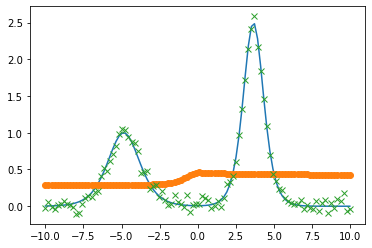

In [27]:
frame = 5
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

Which is pretty good. If we would calculate the mse and reg at this point, we'd get:

In [28]:
from jax.scipy.stats import norm

In [29]:
sigma_mse = jnp.sqrt(jnp.mean((y - prediction)**2))
L_mse = jnp.sum(norm.logpdf((y-prediction), scale=sigma_mse))

print(sigma_mse, L_mse)

0.5746574 -864.9573


In [30]:
sigma_reg = jnp.sqrt(jnp.mean((dt - theta @ coeffs)**2))
L_reg = jnp.sum(norm.logpdf((dt-theta @ coeffs), scale=sigma_reg))

print(sigma_reg, L_reg)

0.009145517 3275.553


And the coeffs:

In [31]:
coeffs * jnp.linalg.norm(theta, axis=0)[:, None]

DeviceArray([[  5.889843 ],
             [  8.006914 ],
             [ -4.0249777],
             [  8.37826  ],
             [-13.896312 ],
             [ -5.7320647],
             [  1.7205676],
             [-17.713785 ],
             [  8.2967   ],
             [ -1.9139442],
             [  1.992955 ],
             [  9.149637 ]], dtype=float32)

In [32]:
obs = jnp.concatenate([y - prediction, dt - theta @ coeffs], axis=1)
rho = jnp.corrcoef(obs.T)[0, 1]
cov = jnp.array([[sigma_mse**2, rho * sigma_mse * sigma_reg], 
                 [rho * sigma_mse * sigma_reg, sigma_reg**2]])

In [33]:
rho

DeviceArray(-0.80341893, dtype=float32)

In [34]:
cov

DeviceArray([[ 3.3023110e-01, -4.2223996e-03],
             [-4.2223996e-03,  8.3640480e-05]], dtype=float32)

In [35]:
L_reg_2D = jnp.sum(multivariate_normal.logpdf(obs, mean=jnp.zeros((2, )), cov=cov))

In [36]:
L_reg_2D

DeviceArray(2928.6802, dtype=float32)

okay so this doesn't seem to work...